In [1]:
import pandas as pd
import numpy as np
dados_oficiais = {
    1960: {"Sede": "Itália", "Medalhas Anterior": np.nan, "Medalhas na Sede": 80, "Medalhas Posterior": 45},
    1964: {"Sede": "Japão", "Medalhas Anterior": 0, "Medalhas na Sede": 10, "Medalhas Posterior": 12},
    1968: {"Sede": "Israel", "Medalhas Anterior": 22, "Medalhas na Sede": 62, "Medalhas Posterior": 28},
    1972: {"Sede": "Alemanha", "Medalhas Anterior": 35, "Medalhas na Sede": 67, "Medalhas Posterior": 37},
    1976: {"Sede": "Canadá", "Medalhas Anterior": 19, "Medalhas na Sede": 77, "Medalhas Posterior": 130},
    1980: {"Sede": "Países Baixos", "Medalhas Anterior": 24, "Medalhas na Sede": 100, "Medalhas Posterior": 135},
    1984: {"Sede": "Estados Unidos", "Medalhas Anterior": 195, "Medalhas na Sede": 396, "Medalhas Posterior": 273},
    1988: {"Sede": "Coreia do Sul", "Medalhas Anterior": 4, "Medalhas na Sede": 94, "Medalhas Posterior": 43},
    1992: {"Sede": "Espanha", "Medalhas Anterior": 43, "Medalhas na Sede": 107, "Medalhas Posterior": 106},
    1996: {"Sede": "Estados Unidos", "Medalhas Anterior": 175, "Medalhas na Sede": 158, "Medalhas Posterior": 109},
    2000: {"Sede": "Austrália", "Medalhas Anterior": 106, "Medalhas na Sede": 149, "Medalhas Posterior": 101},
    2004: {"Sede": "Grécia", "Medalhas Anterior": 11, "Medalhas na Sede": 20, "Medalhas Posterior": 24},
    2008: {"Sede": "China", "Medalhas Anterior": 63, "Medalhas na Sede": 211, "Medalhas Posterior": 231},
    2012: {"Sede": "Grã-Bretanha", "Medalhas Anterior": 102, "Medalhas na Sede": 120, "Medalhas Posterior": 147},
    2016: {"Sede": "Brasil", "Medalhas Anterior": 43, "Medalhas na Sede": 72, "Medalhas Posterior": 72},
    2020: {"Sede": "Japão", "Medalhas Anterior": 24, "Medalhas na Sede": 51, "Medalhas Posterior": 41},
    2024: {"Sede": "França", "Medalhas Anterior": 54, "Medalhas na Sede": 75, "Medalhas Posterior": np.nan}
}

analise_para = []
for ano, dados in dados_oficiais.items():
    linha = {"Ano": ano}
    linha.update(dados)
    analise_para.append(linha)

df_resultado = pd.DataFrame(analise_para)

for col in ["Medalhas Anterior", "Medalhas na Sede", "Medalhas Posterior"]:
     df_resultado[col] = df_resultado[col].astype('Int64')

df_resultado.to_csv("resultado_efeito_casa_paralimpiadas.csv", index=False)

print("--- ANÁLISE DO EFEITO CASA (PARALIMPÍADAS) OFICIAL ---")
print(df_resultado.to_string(index=False))


--- ANÁLISE DO EFEITO CASA (PARALIMPÍADAS) OFICIAL ---
 Ano           Sede  Medalhas Anterior  Medalhas na Sede  Medalhas Posterior
1960         Itália               <NA>                80                  45
1964          Japão                  0                10                  12
1968         Israel                 22                62                  28
1972       Alemanha                 35                67                  37
1976         Canadá                 19                77                 130
1980  Países Baixos                 24               100                 135
1984 Estados Unidos                195               396                 273
1988  Coreia do Sul                  4                94                  43
1992        Espanha                 43               107                 106
1996 Estados Unidos                175               158                 109
2000      Austrália                106               149                 101
2004         Grécia  

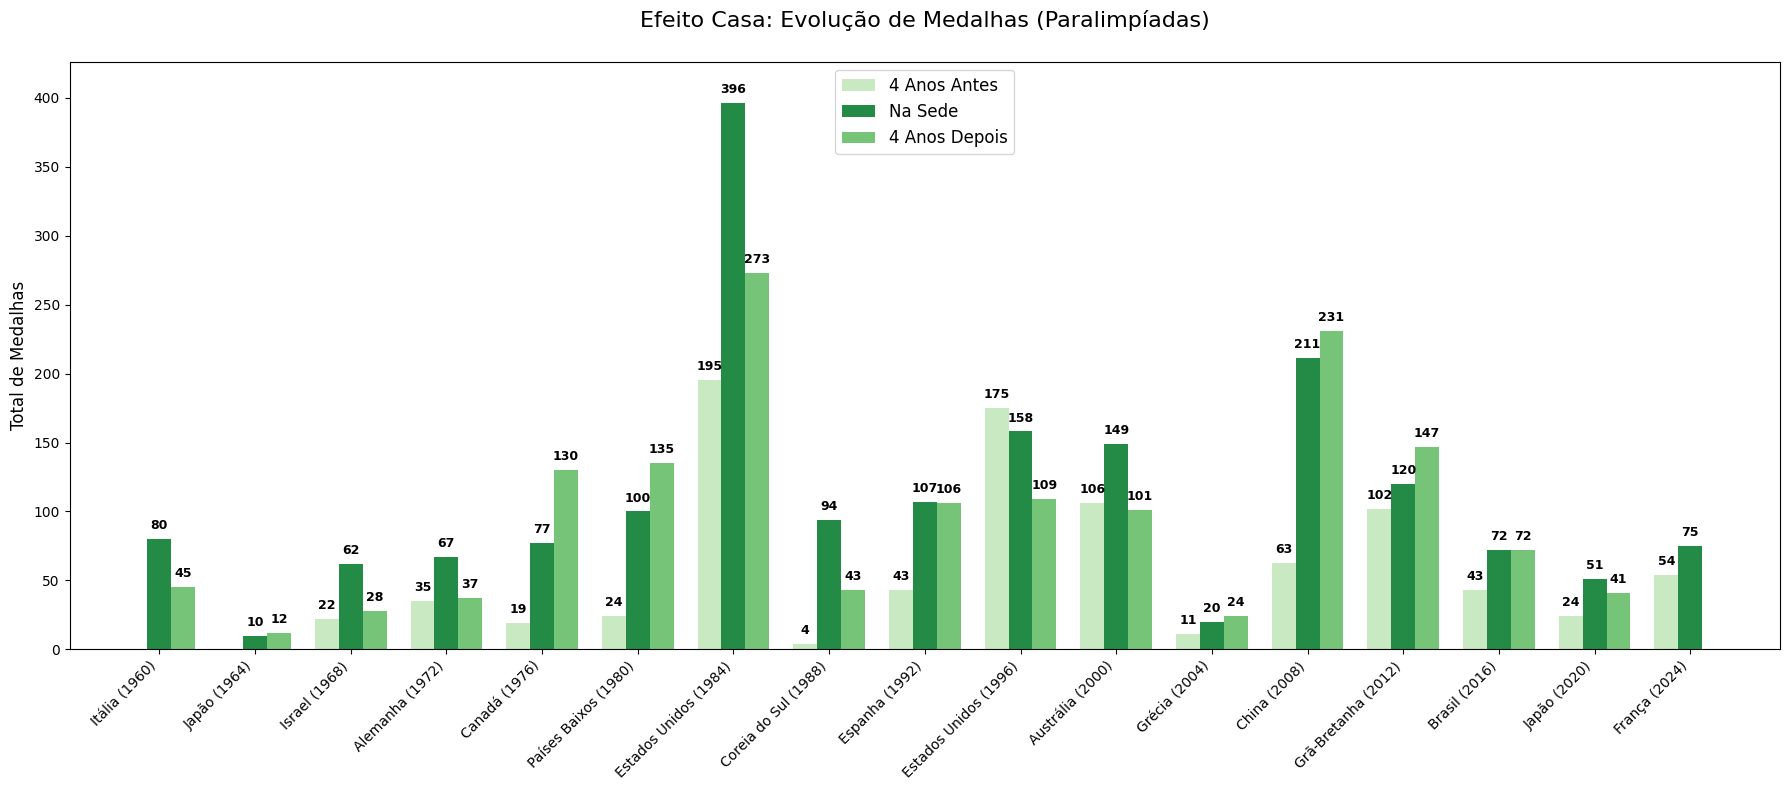

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_para = pd.read_csv("resultado_efeito_casa_paralimpiadas.csv")
df_para = df_para.sort_values('Ano')

df_para['Label'] = df_para['Sede'] + " (" + df_para['Ano'].astype(str) + ")"

x = np.arange(len(df_para))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 8))

paleta_para = sns.color_palette("Greens_r", 3)
cor_na_sede = paleta_para[0]    
cor_posterior = paleta_para[1]  
cor_anterior = paleta_para[2]  

rects1 = ax.bar(x - width, df_para['Medalhas Anterior'], width, label='4 Anos Antes', color=cor_anterior)
rects2 = ax.bar(x, df_para['Medalhas na Sede'], width, label='Na Sede', color=cor_na_sede)
rects3 = ax.bar(x + width, df_para['Medalhas Posterior'], width, label='4 Anos Depois', color=cor_posterior)

ax.set_ylabel('Total de Medalhas', fontsize=12)
ax.set_title('Efeito Casa: Evolução de Medalhas (Paralimpíadas)', fontsize=16, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(df_para['Label'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)

def autolabel_para(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate('{}'.format(int(height)),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel_para(rects1)
autolabel_para(rects2)
autolabel_para(rects3)

ax.set_ylim(0, df_para['Medalhas na Sede'].max() + 30)

plt.tight_layout()
plt.savefig("grafico_efeito_casa_paralimpiadas.png", dpi=300)
plt.show()

Correlação de Pearson (Paralimpíadas): 0.82


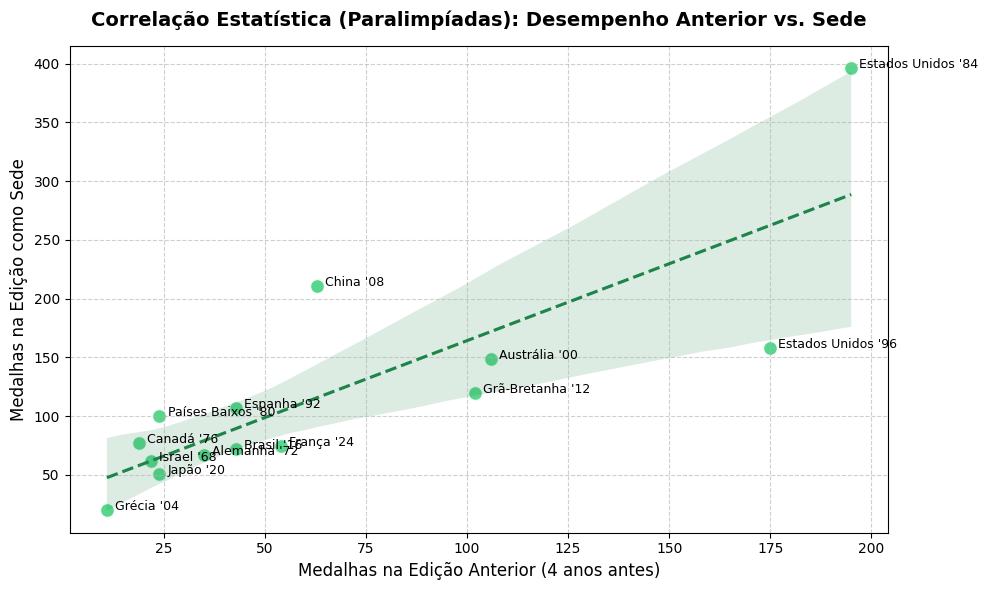

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_para = pd.read_csv("resultado_efeito_casa_paralimpiadas.csv")

df_clean_para = df_para.dropna(subset=['Medalhas Anterior', 'Medalhas na Sede'])
df_clean_para = df_clean_para[df_clean_para['Medalhas Anterior'] > 0].copy()

correlacao = df_clean_para['Medalhas Anterior'].corr(df_clean_para['Medalhas na Sede'])
print(f"Correlação de Pearson (Paralimpíadas): {correlacao:.2f}")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean_para, 
    x='Medalhas Anterior', 
    y='Medalhas na Sede', 
    scatter_kws={'s': 100, 'color': '#2ecc71', 'edgecolor': 'white'}, # Bolinhas verdes
    line_kws={'color': '#1e8449', 'linestyle': '--'} # Linha verde mais escura
)

for i in range(df_clean_para.shape[0]):
    ano_abreviado = str(int(df_clean_para['Ano'].iloc[i]))[2:]
    plt.text(
        df_clean_para['Medalhas Anterior'].iloc[i] + 2, 
        df_clean_para['Medalhas na Sede'].iloc[i], 
        f"{df_clean_para['Sede'].iloc[i]} '{ano_abreviado}", 
        fontsize=9
    )

plt.title('Correlação Estatística (Paralimpíadas): Desempenho Anterior vs. Sede', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medalhas na Edição Anterior (4 anos antes)', fontsize=12)
plt.ylabel('Medalhas na Edição como Sede', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('grafico_correlacao_linha_paralimpiadas.png', dpi=300)
plt.show()